1. CLASSIFICATION DECISION TRESS

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#defining function to calculate minimum gini for given feature
def GiniImpurity(feature, feature_avg):

    gini_total = np.zeros(2999)
    min_gini = float('inf')

    for j in range(2999):
        leaf1 = m[feature < feature_avg[j]]
        leaf2 = m[feature >= feature_avg[j]]
        
        # Process Leaf 1
        n1 = len(leaf1)
        if n1 > 0:
            P1Yes = np.sum(leaf1 == 1) / n1
            P1No = np.sum(leaf1 == 0) / n1
            gini1 = 1 - (P1Yes**2 + P1No**2)
        else:
            gini1 = 0 # Pure or empty
            
        # Process Leaf 2
        n2 = len(leaf2)
        if n2 > 0:
            P2Yes = np.sum(leaf2 == 1) / n2
            P2No = np.sum(leaf2 == 0) / n2
            gini2 = 1 - (P2Yes**2 + P2No**2)
        else:
            gini2 = 0
            
        # Weighted Average Gini
        gini_total[j] = (n1/3000)*gini1 + (n2/3000)*gini2
        
        # Update minimum
        if gini_total[j] < min_gini:
            min_gini = gini_total[j]

    return min_gini



In [63]:
df=pd.read_csv('new_placement_data.csv')
       

In [64]:
df_sorted = df.sort_values(by='CGPA')  #sorting df according to CGPA column
cgpa=df_sorted['CGPA'].values
proj=df_sorted['Projects'].values
m=df_sorted['Placed'].values

In [65]:
#creating arrays to store avg values of two consecutive values of 'CGPA' and 'Projects'
cgpa_avg=[0]*2999
proj_avg=[0]*2999
for i in range(2999):
    cgpa_avg[i]=(cgpa[i]+cgpa[i+1])/2
    proj_avg[i]=(proj[i]+proj[i+1])/2

#calculating minimum gini for CGPA feature
minimum=GiniImpurity(cgpa, cgpa_avg)
print('The minimum gini impurity for CGPA column=',minimum)

The minimum gini impurity for CGPA column= 0.3588954074074074


In [66]:

df_sorted = df.sort_values(by='Projects')   # sorting sf as per Projects column
cgpa=df_sorted['CGPA'].values
proj=df_sorted['Projects'].values
m=df_sorted['Placed'].values


In [67]:
#creating arrays to store avg values of two consecutive values of 'CGPA' and 'Projects'
cgpa_avg=[0]*2999
proj_avg=[0]*2999
for i in range(2999):
    cgpa_avg[i]=(cgpa[i]+cgpa[i+1])/2
    proj_avg[i]=(proj[i]+proj[i+1])/2

#calculating minimum gini for Projects feature
minimum=GiniImpurity(proj, proj_avg)
print('The minimum gini impurity for Projects column=',minimum)

The minimum gini impurity for Projects column= 0.4342140137127068


1. Since gini impurity for CGPA is less than that for Projects, root node will be CGPA.

2. Plotting the decision tree

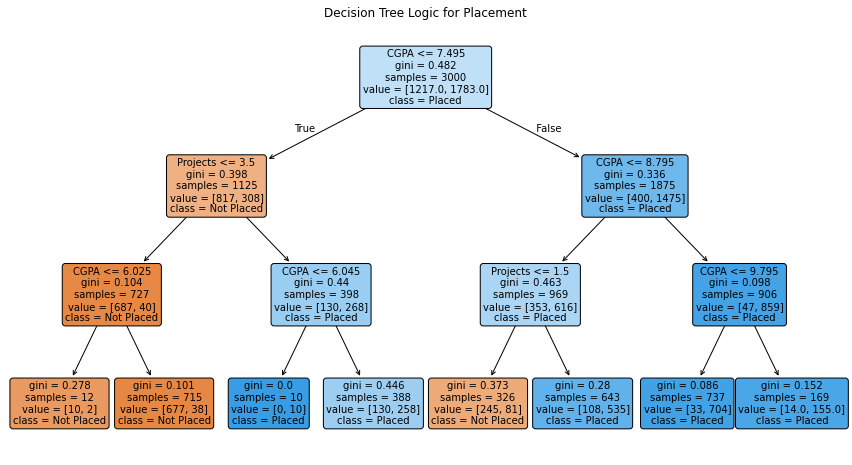

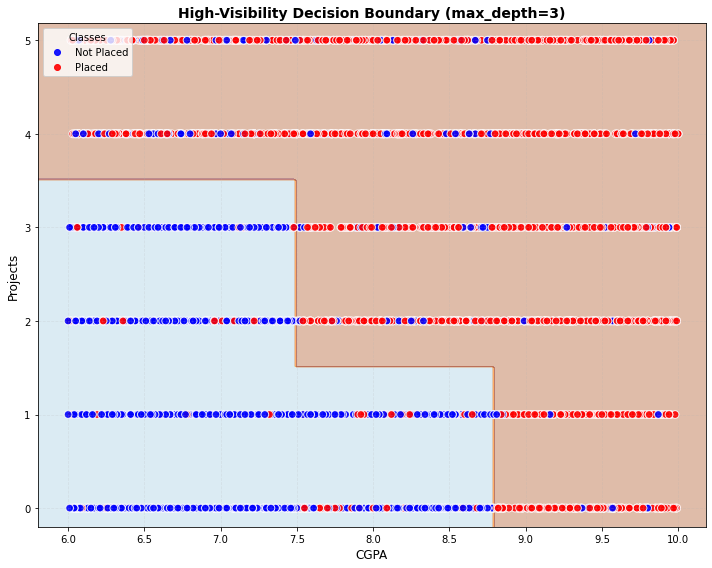

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Prepare the Data
features = ['CGPA', 'Projects'] 
X = df[features]
y = df['Placed']

# 2. Initialize and Train the Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# 3. Plot the Tree Structure
plt.figure(figsize=(15, 8))
plot_tree(clf, 
          feature_names=features,
          class_names=['Not Placed', 'Placed'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Logic for Placement")
plt.show()

# 4. Define Function to Plot Decision Surface (Enhanced Visibility)
def plot_surface(model, X_data, y_data, ax, title, feature_names):
    # Extract values for meshgrid
    X_vals = X_data.values if hasattr(X_data, 'values') else X_data
    
    x_min, x_max = X_vals[:, 0].min() - 0.2, X_vals[:, 0].max() + 0.2
    y_min, y_max = X_vals[:, 1].min() - 0.2, X_vals[:, 1].max() + 0.2
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict over the grid
    grid_data = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=feature_names)
    Z = model.predict(grid_data)
    Z = Z.reshape(xx.shape)
    
    # 1. Use 'Spectral' or 'coolwarm' for more vibrant background regions
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='Paired') 
    
    # 2. Use 'bright' colors for the points and increase size (s=50 or s=100)
    # edgecolors='white' makes points stand out against dark backgrounds
    scatter = ax.scatter(X_vals[:, 0], X_vals[:, 1], c=y_data, 
                         s=60, cmap='bwr', edgecolors='white', 
                         linewidth=1, alpha=0.9)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(feature_names[0], fontsize=12)
    ax.set_ylabel(feature_names[1], fontsize=12)
    
    # Add a legend to explain the colors
    handles, labels = scatter.legend_elements()
    ax.legend(handles, ['Not Placed', 'Placed'], loc="upper left", title="Classes")

# 5. Create and Display the Decision Surface
fig, ax = plt.subplots(figsize=(10, 8)) # Increased figure size
plot_surface(clf, X, y, ax, "High-Visibility Decision Boundary (max_depth=3)", features)
plt.grid(True, linestyle='--', alpha=0.2) # Light grid for better spatial reference
plt.tight_layout()
plt.show()

1. Identify the ”Builder Path.” For students with a CGPA below 8.0, how many
projects does the tree determine they need to be ”Placed"?

2. To find the requirement for a student with a CGPA below 8.0 (specifically within the range of approximately 7.5 to 8.0 based on the root split), we follow these branches:

i. Root node-> right node (CGPA <=8.795)-> left node (projects<=1.5)-> right node (placed)
ii. Therefore, 2 project atleast required for cgpa range [7.5,8] to get placed

2. REGRESSION DECISION TREES

In [69]:
df=pd.read_csv('regression_tree.csv')

1. For depth=2

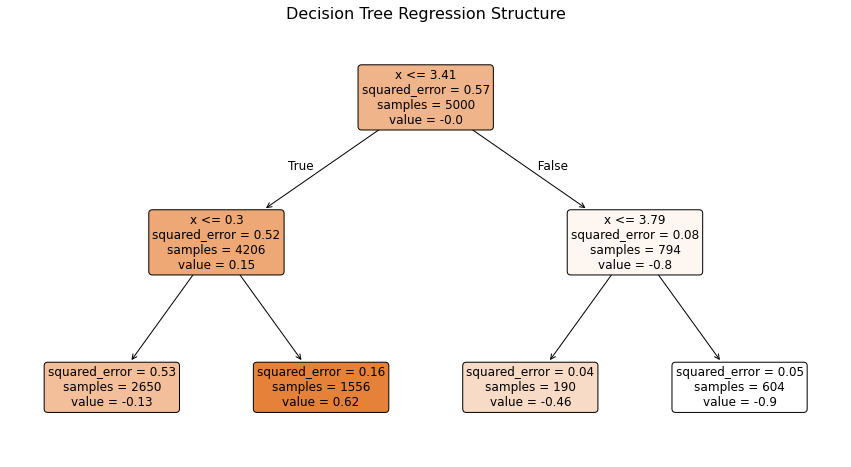

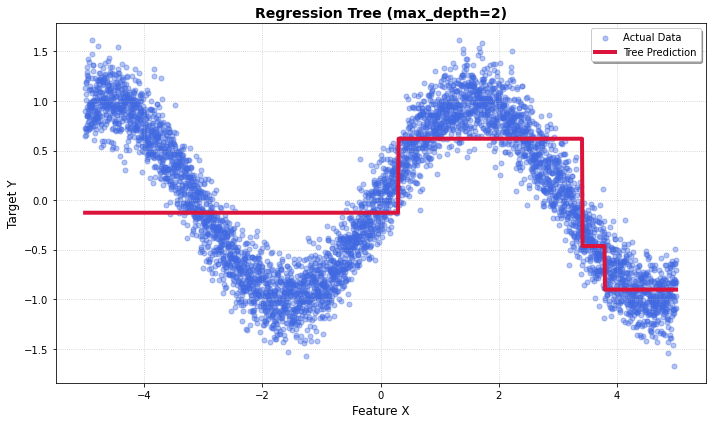

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Prepare the Data correctly
# Explicitly define features to match the single column 'x'
features = ['x'] 
X = df[features]
y = df['y']

# 2. Initialize and Train
reg_tree = DecisionTreeRegressor(max_depth=2, random_state=42)
reg_tree.fit(X, y)

# 3. Plot the Tree Structure
plt.figure(figsize=(15, 8))
plot_tree(reg_tree, 
          feature_names=features,
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2) # Limits decimals for cleaner look
plt.title("Decision Tree Regression Structure", fontsize=16)
plt.show()

# 4. Corrected & High-Visibility Visualization
plt.figure(figsize=(10, 6))

# Create prediction range
x_range_array = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range_array, columns=features) # Fixed columns here

y_pred_range = reg_tree.predict(x_range_df)

# Bolder colors for visibility
# 'royalblue' for points and a thick 'crimson' for the prediction line
plt.scatter(X, y, color='royalblue', label='Actual Data', alpha=0.4, s=25)
plt.plot(x_range_array, y_pred_range, color='crimson', linewidth=4, label='Tree Prediction', zorder=3)

plt.title(f"Regression Tree (max_depth=2)", fontsize=14, fontweight='bold')
plt.xlabel("Feature X", fontsize=12)
plt.ylabel("Target Y", fontsize=12)
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

1. For depth = 10

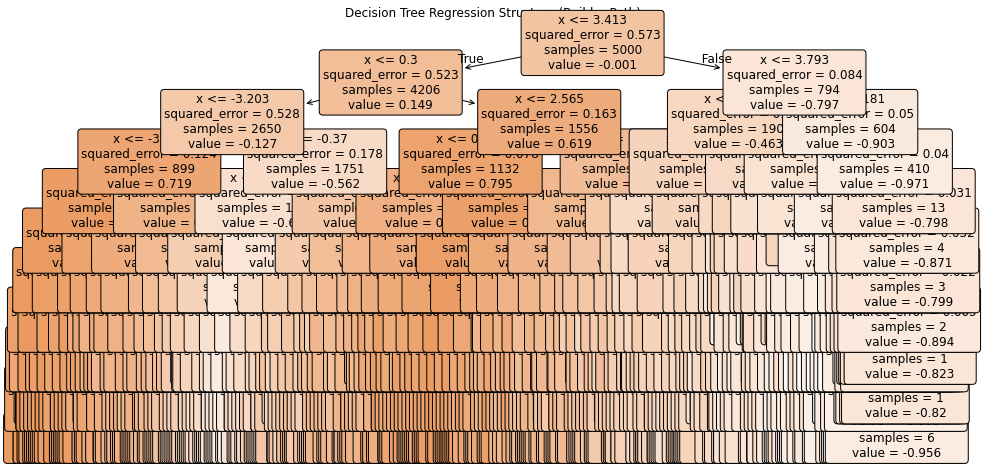

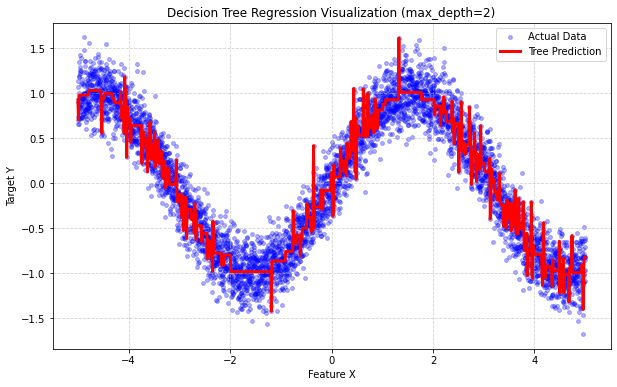

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Prepare the Data
# Define your feature list clearly
X = df[['x']]
y = df['y']

# 2. Initialize and Train the Decision Tree
reg_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
reg_tree.fit(X, y)

# 3. Plot the Tree Structure
plt.figure(figsize=(15, 8))
plot_tree(reg_tree, 
          feature_names=features,
          # Note: class_names is removed because this is regression, not classification
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Decision Tree Regression Structure (Builder Path)")
plt.show()

# 4. Corrected Visualization for 1D Regression
plt.figure(figsize=(10, 6))

# Create a smooth range of X values for prediction
# We use pd.DataFrame to keep the feature name 'x' consistent with training to avoid warnings
x_range_array = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range_array, columns=features) 

# Predict using the DataFrame
y_pred_range = reg_tree.predict(x_range_df)

# Plot actual data points (Blue)
plt.scatter(X, y, color='blue', label='Actual Data', alpha=0.3, s=15)

# Plot the tree's predictions (Red line)
# Note: we use x_range_array here for the x-axis values
plt.plot(x_range_array, y_pred_range, color='red', linewidth=3, label='Tree Prediction')

plt.title(f"Decision Tree Regression Visualization (max_depth=2)")
plt.xlabel("Feature X")
plt.ylabel("Target Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

3. PRUNING TREES

In [72]:
df=pd.read_csv('moons_tree.csv')

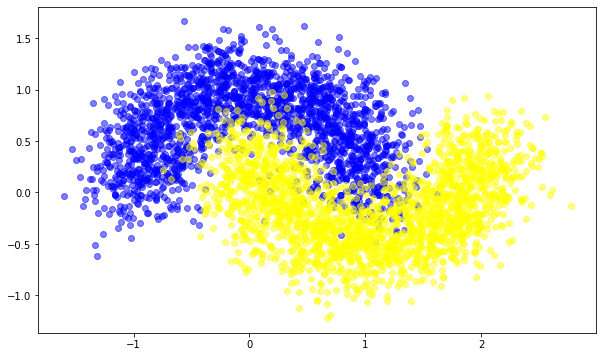

In [73]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.20, random_state=42)

# Extracting values for training set
x1_train = train_df['x1'].values
x2_train = train_df['x2'].values
y_train = train_df['y'].values

x1_val = val_df['x1'].values
x2_val = val_df['x2'].values
y_val = val_df['y'].values

plt.figure(figsize=(10,6))
plt.scatter(x1_train[y_train==-1], x2_train[y_train==-1] ,color="blue",alpha=0.5,label='Original Data')
plt.scatter(x1_train[y_train==1], x2_train[y_train==1] ,color="yellow",alpha=0.5,label='Original Data')

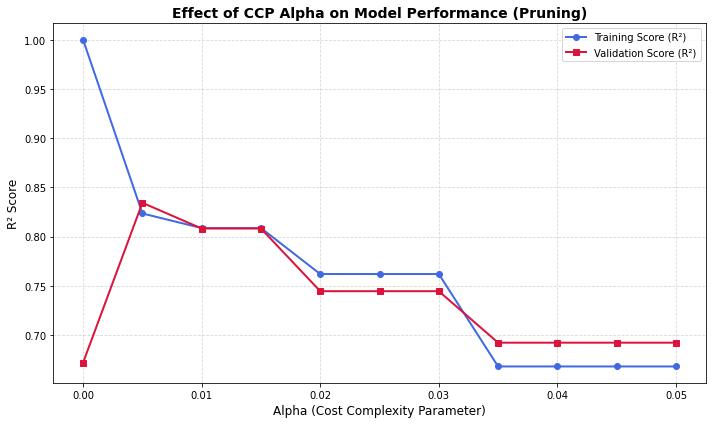

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

# 1. Initialize lists to store scores for plotting
train_acc_list = []
val_acc_list = []
alphas = np.arange(0, 0.055, 0.005)

# 2. Preparation of features (Ensure these exist in your dataframes)
X_train = train_df[['x1', 'x2']]
y_train = train_df['y']
X_val = val_df[['x1', 'x2']]
y_val = val_df['y']

# 3. Loop through alpha values
for a in alphas:
    # Initialize and Fit on training data
    reg_tree = DecisionTreeRegressor(ccp_alpha=a, random_state=42)
    reg_tree.fit(X_train, y_train)
    
    # Calculate scores (R² score is the standard "accuracy" for regression)
    train_score = reg_tree.score(X_train, y_train)
    val_score = reg_tree.score(X_val, y_val)
    
    # Store results in lists
    train_acc_list.append(train_score)
    val_acc_list.append(val_score)

# 4. Plotting the results
plt.figure(figsize=(10, 6))

# Plot both lines with distinct markers and bright colors
plt.plot(alphas, train_acc_list, marker='o', label='Training Score (R²)', color='royalblue', linewidth=2)
plt.plot(alphas, val_acc_list, marker='s', label='Validation Score (R²)', color='crimson', linewidth=2)

# Labeling and Styling
plt.title('Effect of CCP Alpha on Model Performance (Pruning)', fontsize=14, fontweight='bold')
plt.xlabel('Alpha (Cost Complexity Parameter)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. Therefore, the optimum value of alpha is 0.005

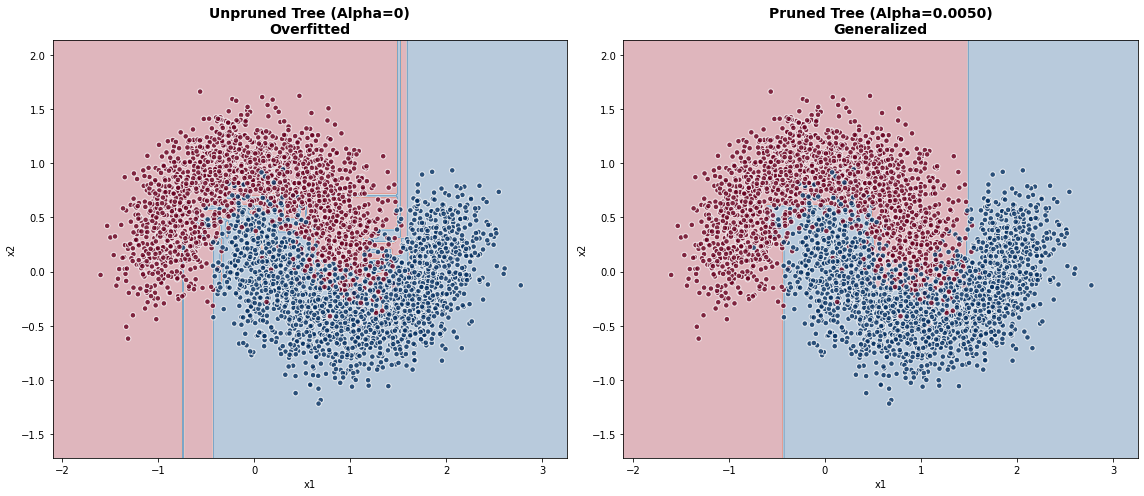

In [75]:

from sklearn.tree import DecisionTreeClassifier

# 0. Preparation (Assuming X_train, y_train, val_df exist from your previous steps)
# Determine opt_alpha (Taking the alpha that gave the best validation score)
best_index = np.argmax(val_acc_list)
opt_alpha = alphas[best_index]

# 1. Initialize and Fit the two trees
tree_1 = DecisionTreeClassifier(ccp_alpha=0, random_state=42).fit(X_train, y_train)
tree_2 = DecisionTreeClassifier(ccp_alpha=opt_alpha, random_state=42).fit(X_train, y_train)

# 2. Update the plot_surface function to be "ax-aware"
def plot_surface(model, ax, title):
    # Use the training features
    X_vals = X_train.values
    feature_names = X_train.columns
    
    # Define bounds
    x_min, x_max = X_vals[:, 0].min() - 0.5, X_vals[:, 0].max() + 0.5
    y_min, y_max = X_vals[:, 1].min() - 0.5, X_vals[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict over grid (Wrapped in DataFrame to match feature names)
    grid_data = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=feature_names)
    Z = model.predict(grid_data)
    Z = Z.reshape(xx.shape)
    
    # Plotting on the specific axis (ax)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_vals[:, 0], X_vals[:, 1], c=y_train, s=30, cmap='RdBu', edgecolors='white', alpha=0.8)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])

# 3. Create and Display the comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

plot_surface(tree_1, ax1, f"Unpruned Tree (Alpha=0)\nOverfitted")
plot_surface(tree_2, ax2, f"Pruned Tree (Alpha={opt_alpha:.4f})\nGeneralized")

plt.tight_layout()
plt.show()

1. Question: Describe the geometric shape of the boundaries. Why are there only horizontal and
vertical lines?

1. It is because we assign one value of y for a colection of x values, therefore steps-like boundaries are created.

In [76]:
reg_tree = DecisionTreeRegressor(ccp_alpha=0, random_state=42)
reg_tree.fit(X_train, y_train)

# Assuming your model is 'clf' or 'reg_tree'
actual_depth = clf.get_depth()

print(f"The tree has a depth of: {actual_depth}")

The tree has a depth of: 3


In [77]:
reg_tree = DecisionTreeRegressor(ccp_alpha=0.005, random_state=42)
reg_tree.fit(X_train, y_train)

# Assuming your model is 'clf' or 'reg_tree'
actual_depth = clf.get_depth()

print(f"The tree has a depth of: {actual_depth}")

The tree has a depth of: 3
